# Notebook 01a -- Model Demonstration, Pilario & Cao Parameter Set

This is the legacy-comparison companion to
[`01_model_demonstration.ipynb`](01_model_demonstration.ipynb). The structure
is identical, but the physical and controller constants are the **Pilario &
Cao (2018)** benchmark values used in the legacy code -- summarised in
[`../../legacy_code/docs/cstr-sbi.tex`](../../legacy_code/docs/cstr-sbi.tex)
and originally implemented in
[`../../legacy_code/sbi/tools.py`](../../legacy_code/sbi/tools.py).

The reasons to keep this notebook:

* It validates the JAX/diffrax simulator against the **published reference
  results** for the legacy parameter set (`C = 0.11 mol/L`, `T = 428.7 K`,
  `Tc = 415.1 K`, `Qc -> 147 L/min` when controlled to `Tsp = 430 K`).
* It exhibits the **classic multiple-steady-state structure** (a high-T
  ignited branch around 430 K and a low-T extinction branch around 357 K)
  that motivated the original Pilario benchmark.
* It demonstrates that the headline phenomenon of notebook 01 (`Qc`
  carries the fault signal that `T` masks) is *not specific* to the
  Fogler-grounded chemistry -- it generalises to a different parameter
  regime and reactor scale.

> **Note.** The Pilario parameter set has known issues for use as a
> physically-faithful PO-hydrolysis simulator (most notably
> `H_r = -2.0e5 cal/mol`, ten times the experimental value); see
> [`../../cstr_parameters_recommended.md`](../../cstr_parameters_recommended.md)
> for the full discussion. Notebook 01 (Fogler-grounded) is the version
> used by all downstream milestones; this notebook is for legacy
> reproduction only.


## 1. Constants and locally-defined ODE right-hand sides

We do not modify ``cstr_sbi.physics`` (which encodes the Fogler set);
instead we redefine the open-loop and closed-loop RHS locally in this
notebook so that all module-level constants are taken from the legacy
Pilario set.


In [1]:
import time
import jax
import jax.numpy as jnp
import diffrax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ---------------------------------------------------------------------
# Legacy Pilario & Cao (2018) constants  (legacy_code/docs/cstr-sbi.tex
# and legacy_code/sbi/tools.py).  Calorie unit system.
# ---------------------------------------------------------------------
V_LEG     = 150.0     # L,           reactor volume
VC_LEG    = 10.0      # L,           jacket volume
Q_LEG     = 100.0     # L/min,       feed flow rate         (tau = 1.5 min)
EA_LEG    = 83140.0   # J/mol,       activation energy
R_GAS     = 8.314     # J/(K mol)
HR_LEG    = -2.0e5    # cal/mol,     heat of reaction (10x larger than Fogler)
CP_LEG    = 1.0       # cal/(g K)
CPC_LEG   = 1.0       # cal/(g K)
RHO_LEG   = 1000.0    # g/L
RHOC_LEG  = 1000.0    # g/L

# True parameters (Pilario benchmark)
UA_LEG    = 7.0e5     # cal/(min K)
K0_LEG    = 7.2e10    # 1/min

# Legacy nominal feed conditions (from legacy_code/sbi/tools.py __main__
# and the legacy doc's "validation" run)
CI_LEG    = 0.97      # mol/L
TI_LEG    = 351.5     # K
TCI_LEG   = 351.6     # K
QC_OL     = 150.0     # L/min,  fixed Qc for the open-loop validation run

# Legacy PI controller settings.
#   The legacy doc states tau_i = 0.5 min "for controller stability".
#   The other constants (Kp, Qc0, Qc_min, Qc_max) are not given in the
#   doc; we choose values consistent with the doc's reported result
#   (Qc -> 147 L/min when controlled to Tsp = 430 K) and the avoidance
#   of the extinction branch at Qc >~ 165 L/min.
TSP_LEG    = 430.0    # K
KP_LEG     = 2.0      # (L/min)/K
TAUI_LEG   = 0.5      # min  (legacy doc, Section 3)
QC0_LEG    = 150.0    # L/min  (bias matching the legacy validation Qc)
QCMIN_LEG  = 50.0     # L/min
QCMAX_LEG  = 200.0    # L/min  (kept below the extinction Qc ~ 165)

print("=== Pilario & Cao 2018 constants ===")
print(f"  Reactor : V = {V_LEG} L,  V_c = {VC_LEG} L,  Q = {Q_LEG} L/min  (tau = {V_LEG/Q_LEG} min)")
print(f"  Kinetics: k0 = {K0_LEG:.2e} 1/min,  Ea = {EA_LEG} J/mol,  Hr = {HR_LEG:.2e} cal/mol")
print(f"  Heat tx : UA = {UA_LEG:.2e} cal/(min K)")
print(f"  Inlet   : Ci = {CI_LEG} mol/L,  Ti = {TI_LEG} K,  Tci = {TCI_LEG} K")
print(f"  PI ctrl : Tsp = {TSP_LEG} K,  Kp = {KP_LEG},  tau_i = {TAUI_LEG} min,  Qc0 = {QC0_LEG}")
print(f"            Qc range = [{QCMIN_LEG}, {QCMAX_LEG}] L/min")

=== Pilario & Cao 2018 constants ===
  Reactor : V = 150.0 L,  V_c = 10.0 L,  Q = 100.0 L/min  (tau = 1.5 min)
  Kinetics: k0 = 7.20e+10 1/min,  Ea = 83140.0 J/mol,  Hr = -2.00e+05 cal/mol
  Heat tx : UA = 7.00e+05 cal/(min K)
  Inlet   : Ci = 0.97 mol/L,  Ti = 351.5 K,  Tci = 351.6 K
  PI ctrl : Tsp = 430.0 K,  Kp = 2.0,  tau_i = 0.5 min,  Qc0 = 150.0
            Qc range = [50.0, 200.0] L/min


In [2]:
def cstr_open_loop_rhs_leg(t, y, args):
    """Legacy 3-state open-loop CSTR RHS (Pilario constants)."""
    params, inlet = args
    UA, k0 = params[0], params[1]
    Ci, Ti, Tci, Qc = inlet[0], inlet[1], inlet[2], inlet[3]
    C, T, Tc = y[0], y[1], y[2]
    k = k0 * jnp.exp(-EA_LEG / (R_GAS * T))
    dC  = (Q_LEG / V_LEG) * (Ci - C) - k * C
    dT  = ((Q_LEG / V_LEG) * (Ti - T)
           - HR_LEG * k * C / (RHO_LEG * CP_LEG)
           - UA * (T - Tc) / (RHO_LEG * CP_LEG * V_LEG))
    dTc = (Qc / VC_LEG) * (Tci - Tc) + UA * (T - Tc) / (RHOC_LEG * CPC_LEG * VC_LEG)
    return jnp.array([dC, dT, dTc])


def compute_qc_leg(T, I, ctrl):
    Kp, tau_i, Tsp, Qc0, Qc_min, Qc_max = ctrl
    qc_unclamped = Qc0 + Kp * (T - Tsp) + I / tau_i
    return jnp.clip(qc_unclamped, Qc_min, Qc_max)


def cstr_closed_loop_rhs_leg(t, y, args):
    """Legacy 4-state closed-loop CSTR RHS with PI controller, anti-windup
    via conditional integration, and alpha/beta degradation factors."""
    params, inlet, ctrl = args
    UA, k0, alpha, beta = params[0], params[1], params[2], params[3]
    Ci, Ti, Tci = inlet[0], inlet[1], inlet[2]
    Kp, tau_i, Tsp, Qc0, Qc_min, Qc_max = (
        ctrl[0], ctrl[1], ctrl[2], ctrl[3], ctrl[4], ctrl[5],
    )
    C, T, Tc, I = y[0], y[1], y[2], y[3]

    qc_unclamped = Qc0 + Kp * (T - Tsp) + I / tau_i
    Qc = jnp.clip(qc_unclamped, Qc_min, Qc_max)
    not_saturated = (qc_unclamped > Qc_min) & (qc_unclamped < Qc_max)
    dI = jnp.where(not_saturated, T - Tsp, 0.0)

    k_eff  = alpha * k0 * jnp.exp(-EA_LEG / (R_GAS * T))
    UA_eff = beta * UA

    dC  = (Q_LEG / V_LEG) * (Ci - C) - k_eff * C
    dT  = ((Q_LEG / V_LEG) * (Ti - T)
           - HR_LEG * k_eff * C / (RHO_LEG * CP_LEG)
           - UA_eff * (T - Tc) / (RHO_LEG * CP_LEG * V_LEG))
    dTc = (Qc / VC_LEG) * (Tci - Tc) + UA_eff * (T - Tc) / (RHOC_LEG * CPC_LEG * VC_LEG)
    return jnp.array([dC, dT, dTc, dI])


def integrate(rhs, t_final, y0, args, n_save=401, rtol=1e-7, atol=1e-9):
    term = diffrax.ODETerm(rhs)
    saveat = diffrax.SaveAt(ts=jnp.linspace(0.0, t_final, n_save))
    sol = diffrax.diffeqsolve(
        term, diffrax.Tsit5(),
        t0=0.0, t1=t_final, dt0=0.001,
        y0=y0, args=args,
        stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
        saveat=saveat, max_steps=2_000_000, throw=False,
    )
    return np.asarray(sol.ts), np.asarray(sol.ys)


# Defaults for this notebook
PARAMS_OL_LEG  = jnp.array([UA_LEG, K0_LEG])               # 2-D, open loop
PARAMS_CL_LEG  = jnp.array([UA_LEG, K0_LEG, 1.0, 1.0])     # 4-D, closed loop, alpha=beta=1
INLET_OL_LEG   = jnp.array([CI_LEG, TI_LEG, TCI_LEG, QC_OL])
INLET_CL_LEG   = jnp.array([CI_LEG, TI_LEG, TCI_LEG])      # Qc computed by PI
CTRL_LEG       = jnp.array([KP_LEG, TAUI_LEG, TSP_LEG, QC0_LEG, QCMIN_LEG, QCMAX_LEG])

# Warm-start IC near the Pilario open-loop SS at Qc = 150 L/min.
Y0_OL_LEG = jnp.array([0.108, 428.7, 415.1])
Y0_CL_LEG = jnp.array([0.108, 428.7, 415.1, 0.0])

print("Legacy ODE RHS and integrator helpers defined.")

Legacy ODE RHS and integrator helpers defined.


## 2. Open-loop validation (Scenario 0)

Reproducing the legacy doc's reported steady state (`C = 0.1 mol/L`,
`T = 430 K`, `Tc = 416 K` to two significant figures, with `Qc` fixed
at `150 L/min`). The high-tolerance scipy reference is taken as the
unrounded ground truth.


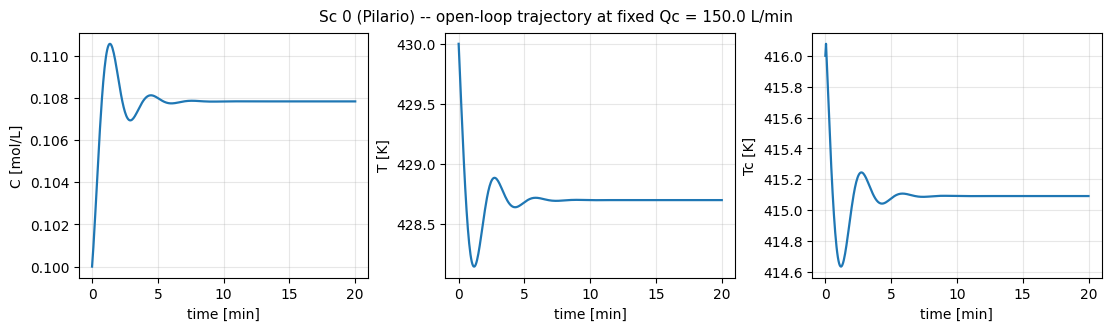


Open-loop steady state at Qc = 150 L/min:
  scipy (RK45, rtol=1e-8) : C = 0.10783 mol/L, T = 428.6966 K,  Tc = 415.0913 K
  JAX/diffrax (Tsit5)     : C = 0.10783 mol/L, T = 428.6966 K,  Tc = 415.0913 K
  legacy doc (2 sf)       : C = 0.10 mol/L, T = 430.0 K, Tc = 416.0 K


In [3]:
def open_loop_traj_legacy(Qc_value, t_final=20.0, n_save=401):
    """Pure-NumPy open-loop integrator (avoids per-step JAX tracing)."""
    Ci, Ti, Tci = float(CI_LEG), float(TI_LEG), float(TCI_LEG)
    UA, k0 = float(UA_LEG), float(K0_LEG)
    def rhs(t, y):
        C, T, Tc = y
        k = k0 * np.exp(-EA_LEG / (R_GAS * T))
        return [
            (Q_LEG / V_LEG) * (Ci - C) - k * C,
            (Q_LEG / V_LEG) * (Ti - T) - HR_LEG * k * C / (RHO_LEG * CP_LEG)
                                       - UA * (T - Tc) / (RHO_LEG * CP_LEG * V_LEG),
            (Qc_value / VC_LEG) * (Tci - Tc) + UA * (T - Tc) / (RHOC_LEG * CPC_LEG * VC_LEG),
        ]
    sol = solve_ivp(
        rhs, (0.0, t_final), [0.1, 430.0, 416.0],
        t_eval=np.linspace(0.0, t_final, n_save),
        method="RK45", rtol=1e-8, atol=1e-10,
    )
    return sol.t, sol.y

t_ol, y_ol = open_loop_traj_legacy(QC_OL, t_final=20.0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), constrained_layout=True)
labels = ["C [mol/L]", "T [K]", "Tc [K]"]
for i, ax in enumerate(axes):
    ax.plot(t_ol, y_ol[i], lw=1.6)
    ax.set_xlabel("time [min]")
    ax.set_ylabel(labels[i])
    ax.grid(alpha=0.3)
fig.suptitle(
    f"Sc 0 (Pilario) -- open-loop trajectory at fixed Qc = {QC_OL} L/min",
    fontsize=11,
)
plt.show()

# Compare scipy reference and JAX
y_jax = np.asarray(integrate(cstr_open_loop_rhs_leg, 20.0,
                             Y0_OL_LEG, (PARAMS_OL_LEG, INLET_OL_LEG),
                             n_save=2)[1][-1])
print()
print("Open-loop steady state at Qc = 150 L/min:")
print(f"  scipy (RK45, rtol=1e-8) : C = {y_ol[0,-1]:.5f} mol/L, "
      f"T = {y_ol[1,-1]:.4f} K,  Tc = {y_ol[2,-1]:.4f} K")
print(f"  JAX/diffrax (Tsit5)     : C = {y_jax[0]:.5f} mol/L, "
      f"T = {y_jax[1]:.4f} K,  Tc = {y_jax[2]:.4f} K")
print(f"  legacy doc (2 sf)       : C = 0.10 mol/L, "
      f"T = 430.0 K, Tc = 416.0 K")

## 3. Closed-loop dynamics (Scenario 1, healthy reactor)

PI controller targeting `Tsp = 430 K`. Because `Q = 100 L/min` and
`V = 150 L`, the residence time is `tau = 1.5 min` -- much faster than
the Fogler set's 12.5 min, so closed-loop equilibration is correspondingly
quick. The legacy doc reports `Qc -> 147 L/min` at steady state, in line
with the open-loop scan: at `Qc = 145` we get `T = 430.87 K` (slight
overshoot above setpoint) and at `Qc = 150` we get `T = 428.70 K` (slight
undershoot), so the controller settles between them.


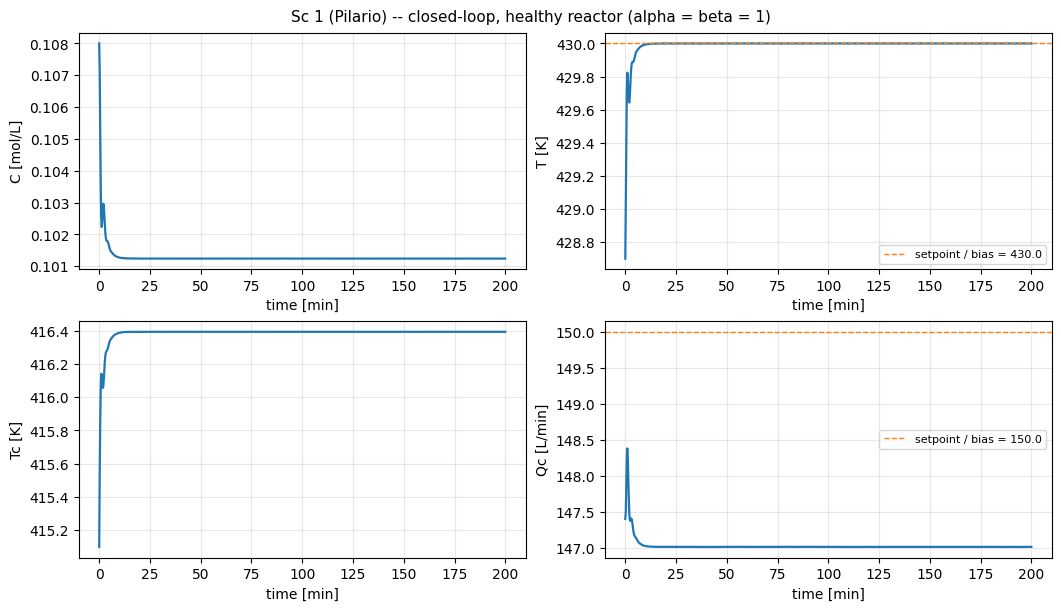

Final state at t = 200 min:
  C  = 0.10124 mol/L
  T  = 430.0002 K   (Tsp = 430.0,   |T - Tsp| = 0.0002)
  Tc = 416.3926 K
  I  = -1.494
  Qc = 147.012 L/min   (legacy doc: ~147 L/min)


In [4]:
t_cl, ys_cl = integrate(cstr_closed_loop_rhs_leg, 200.0,
                        Y0_CL_LEG, (PARAMS_CL_LEG, INLET_CL_LEG, CTRL_LEG),
                        n_save=801)
qc_cl = np.asarray(jax.vmap(compute_qc_leg, in_axes=(0, 0, None))(
    jnp.asarray(ys_cl[:, 1]), jnp.asarray(ys_cl[:, 3]), CTRL_LEG))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6), constrained_layout=True)
panel = [
    ("C [mol/L]",  ys_cl[:, 0], None),
    ("T [K]",      ys_cl[:, 1], TSP_LEG),
    ("Tc [K]",     ys_cl[:, 2], None),
    ("Qc [L/min]", qc_cl,        QC0_LEG),
]
for ax, (lab, y, ref) in zip(axes.ravel(), panel):
    ax.plot(t_cl, y, lw=1.6)
    if ref is not None:
        ax.axhline(ref, color="C1", ls="--", lw=1.0,
                   label=f"setpoint / bias = {ref}")
        ax.legend(loc="best", fontsize=8)
    ax.set_xlabel("time [min]"); ax.set_ylabel(lab); ax.grid(alpha=0.3)
fig.suptitle(
    "Sc 1 (Pilario) -- closed-loop, healthy reactor (alpha = beta = 1)",
    fontsize=11,
)
plt.show()

print("Final state at t = 200 min:")
print(f"  C  = {ys_cl[-1, 0]:.5f} mol/L")
print(f"  T  = {ys_cl[-1, 1]:.4f} K   (Tsp = {TSP_LEG},   |T - Tsp| = {abs(ys_cl[-1,1]-TSP_LEG):.4f})")
print(f"  Tc = {ys_cl[-1, 2]:.4f} K")
print(f"  I  = {ys_cl[-1, 3]:+.3f}")
print(f"  Qc = {qc_cl[-1]:.3f} L/min   (legacy doc: ~147 L/min)")

## 4. The headline phenomenon -- jacket fouling vs catalyst decay

Same construction as in notebook 01, with the legacy parameter set:
fouling raises `Qc`, catalyst decay lowers it; the controller keeps
`T` close to `Tsp` in both healthy and faulty cases.


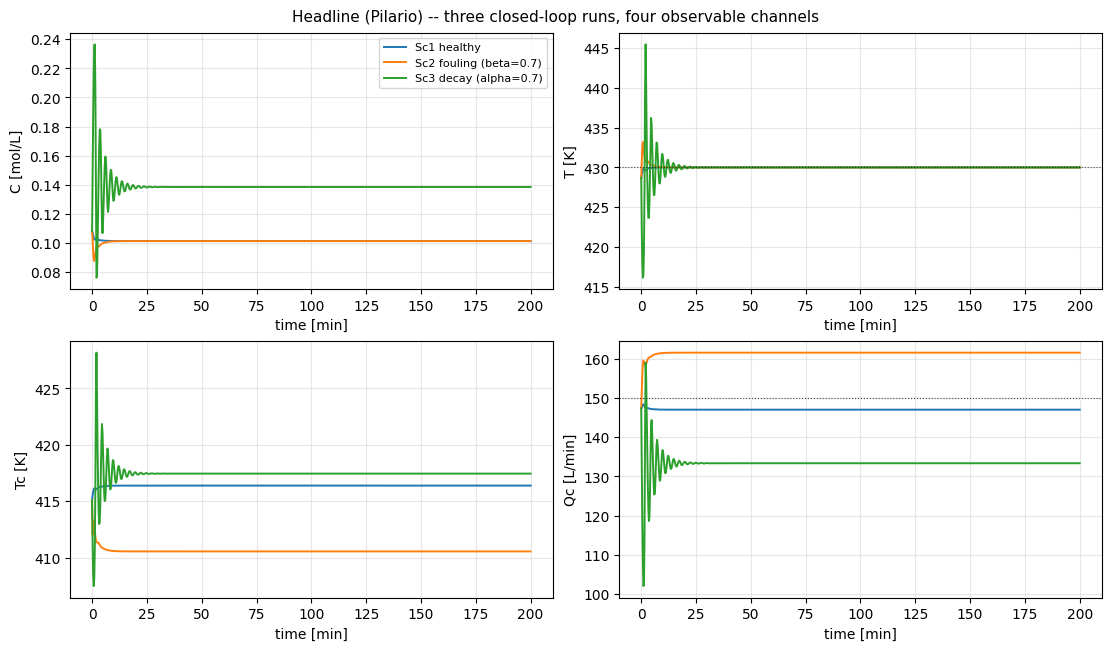

              scenario      C_ss      T_ss     Tc_ss     Qc_ss
           Sc1 healthy    0.1012  430.0002  416.3926  147.0116
Sc2 fouling (beta=0.7)    0.1012  429.9999  410.5607  161.5515
 Sc3 decay (alpha=0.7)    0.1384  429.9999  417.4551  133.3426


In [5]:
def run_legacy_scenario(alpha, beta, label, t_final=200.0):
    params = jnp.array([UA_LEG, K0_LEG, alpha, beta])
    t, ys = integrate(cstr_closed_loop_rhs_leg, t_final, Y0_CL_LEG,
                      (params, INLET_CL_LEG, CTRL_LEG), n_save=801)
    qc = np.asarray(jax.vmap(compute_qc_leg, in_axes=(0, 0, None))(
        jnp.asarray(ys[:, 1]), jnp.asarray(ys[:, 3]), CTRL_LEG))
    return label, t, ys, qc

scenarios = [
    run_legacy_scenario(1.0, 1.0, "Sc1 healthy"),
    run_legacy_scenario(1.0, 0.7, "Sc2 fouling (beta=0.7)"),
    run_legacy_scenario(0.7, 1.0, "Sc3 decay (alpha=0.7)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), constrained_layout=True)
labels = ["C [mol/L]", "T [K]", "Tc [K]", "Qc [L/min]"]
for label, t, ys, qc in scenarios:
    series = [ys[:, 0], ys[:, 1], ys[:, 2], qc]
    for ax, lab, y in zip(axes.ravel(), labels, series):
        ax.plot(t, y, lw=1.4, label=label)
        ax.set_xlabel("time [min]"); ax.set_ylabel(lab); ax.grid(alpha=0.3)
axes[0, 1].axhline(TSP_LEG, color="k", ls=":", lw=0.8, alpha=0.7,
                   label=f"Tsp = {TSP_LEG}")
axes[1, 1].axhline(QC0_LEG, color="k", ls=":", lw=0.8, alpha=0.7,
                   label=f"Qc0 = {QC0_LEG}")
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle(
    "Headline (Pilario) -- three closed-loop runs, four observable channels",
    fontsize=11,
)
plt.show()

rows = []
for label, _, ys, qc in scenarios:
    rows.append({
        "scenario": label,
        "C_ss":  ys[-1, 0],
        "T_ss":  ys[-1, 1],
        "Tc_ss": ys[-1, 2],
        "Qc_ss": qc[-1],
    })
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

## 5. Controller saturation (Scenario 5)

Saturating the upper valve limit by progressively increasing the fouling
factor.  Note that here `Qc_max = 200 L/min` is set deliberately below
the extinction `Qc` (~165 L/min on the cold branch starts at ~170 L/min,
but on the hot branch we have a wider safe range; the saturation regime
in this notebook is the *upper* valve clamp, not the bistability
boundary).


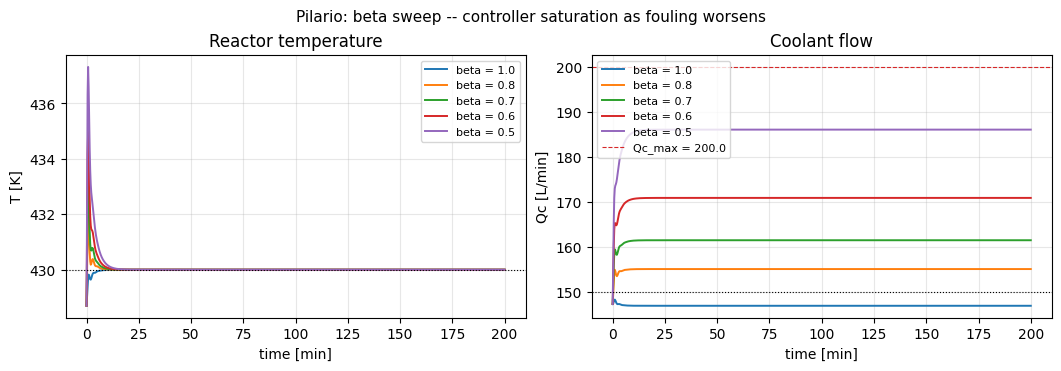

      beta   T_ss [K]  T_ss - Tsp [K]  Qc_ss [L/min] saturated
    1.0000   430.0002          0.0002       147.0116        no
    0.8000   429.9999         -0.0001       155.1570        no
    0.7000   429.9999         -0.0001       161.5515        no
    0.6000   430.0000          0.0000       170.9451        no
    0.5000   429.9999         -0.0001       186.0936        no


In [6]:
sweep_betas = [1.0, 0.8, 0.7, 0.6, 0.5]
rows = []
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), constrained_layout=True)
for beta in sweep_betas:
    label, t, ys, qc = run_legacy_scenario(1.0, beta, f"beta = {beta}",
                                           t_final=200.0)
    axes[0].plot(t, ys[:, 1], lw=1.4, label=label)
    axes[1].plot(t, qc,        lw=1.4, label=label)
    rows.append({
        "beta":           beta,
        "T_ss [K]":       ys[-1, 1],
        "T_ss - Tsp [K]": ys[-1, 1] - TSP_LEG,
        "Qc_ss [L/min]":  qc[-1],
        "saturated":      "yes" if qc[-1] >= QCMAX_LEG - 1e-3 else "no",
    })

axes[0].axhline(TSP_LEG, color="k", ls=":", lw=0.8)
axes[0].set_xlabel("time [min]"); axes[0].set_ylabel("T [K]")
axes[0].set_title("Reactor temperature")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

axes[1].axhline(QCMAX_LEG, color="C3", ls="--", lw=0.8, label=f"Qc_max = {QCMAX_LEG}")
axes[1].axhline(QC0_LEG,   color="k",  ls=":",  lw=0.8)
axes[1].set_xlabel("time [min]"); axes[1].set_ylabel("Qc [L/min]")
axes[1].set_title("Coolant flow")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle("Pilario: beta sweep -- controller saturation as fouling worsens",
             fontsize=11)
plt.show()

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:10.4f}"))

## 6. Comparison -- Pilario vs Fogler at a glance

| Quantity                | Pilario (this nb) | Fogler (nb 01)   |
|-------------------------|-------------------|------------------|
| `H_r` [cal/mol]         | -2.0e5            | -2.02e4          |
| `Ea` [J/mol]            | 83 140            | 75 362           |
| `k0` [1/min]            | 7.2e10            | 1.696e13         |
| `UA` [cal/(min K)]      | 7.0e5             | 1.25e4           |
| `V, V_c, Q`             | 150, 10, 100      | 500, 40, 40      |
| residence time `tau`    | 1.5 min           | 12.5 min         |
| `Tsp`                   | 430 K             | 312.5 K          |
| Healthy `Qc_ss`         | ~147 L/min        | ~48 L/min        |
| Adiabatic dT (`-Hr Ci/(rho Cp)`) | 194 K     | 19.6 K           |

Both regimes show the same qualitative phenomenon -- the controller
masks the fault in `T` and externalises it into `Qc` -- but the Pilario
regime is far more dramatic (10x larger heat of reaction, near a
multi-steady-state bifurcation) and is *not physically representative*
of liquid-phase PO hydrolysis. The downstream SBI study uses the Fogler
parameter set; the Pilario reproduction here is for cross-checking the
JAX/diffrax simulator against the legacy results documented in
`legacy_code/docs/cstr-sbi.tex`.
